In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from scipy import stats

# Date range used across all cells
start_date = "2023-01-01"
end_date   = "2026-03-01"

In [2]:
from ml_utils.snowflake_utils import SnowflakeConnector

snowflake_client = SnowflakeConnector("joshua.choy@transferwise.com")

Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://transferwise.okta-emea.com/app/snowflake/exk4istpb5gZUyV8u0i7/sso/saml?SAMLRequest=nZJNb%2BIwEIb%2FSuQ9JzYBCrWAigWxi%2FqxFAJa9WaSgbhJ7KzHaeDf14Syag%2FtoVIOkfPM5Bm%2FM7g5FLn3AgalVkPSChjxQMU6kWo%2FJOto5veJh1aoRORawZAcAcnNaICiyEs%2BrmyqlvCvArSea6SQNx%2BGpDKKa4ESuRIFILcxX43v73gYMF4abXWsc%2FKu5OsKgQjGOsNLSYLS6aXWlpzSuq6Duh1os6chY4yya%2BqoE%2FLjwh%2FcTJ%2FwLco6J94RDl%2B8uf2U6nwFX2ltzxDy31G08Bd%2FVhHxxhfViVZYFWBWYF5kDOvl3VkAncEyCnudsB9A5cegrBG53wpQ6XqXiwxiXZSVdY0D90Z3kNBc76WbfT4dkjKTyQR3402apd34MdW31d%2FbjBXPv1K5F7K3Lmfr7aNePh8fVLy8j4m3uYQbnsKdI1YwV6dIrTti4ZXP2u6JGOOdNg%2BvgutO94l4UxepVMI2lRdvZ6pwB6aWCIHOrPChANFoirKk%2FyegcMg6Em257e6f1sdNv2KyRxE1PWVNzuvDGxUz%2BsalDOj7Bm%2FL%2BODymU8XOpfx0ZtpUwj7eXytoNWcyMTfNSiHQsh8nCQGEF2Mea7riQFh3c5bUwGho%2FNfP2796BU%3D&RelayState=ver%3A3-hint%3A11514982050242-ETMsDgAAAZyxJlthABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEPCu%2Biz6UIYA8RcHKubu%2BT8AAACgX

## Section 1: Oil Price Data (via yfinance)

In [3]:
# Fetch Brent and WTI crude oil daily data
brent = yf.download("BZ=F", start=start_date, end=end_date, auto_adjust=True)["Close"].squeeze().rename("Brent")
wti   = yf.download("CL=F", start=start_date, end=end_date, auto_adjust=True)["Close"].squeeze().rename("WTI")

oil_df = pd.concat([brent, wti], axis=1).dropna(how="all")
oil_df.index = pd.to_datetime(oil_df.index)
if oil_df.index.tz is not None:
    oil_df.index = oil_df.index.tz_localize(None)

oil_df.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Brent,WTI
Date,,
2026-02-23,71.489998,66.309998
2026-02-24,70.769997,65.629997
2026-02-25,70.849998,65.419998
2026-02-26,70.750000,65.209999
2026-02-27,72.480003,67.019997


## Section 2: FX Rates (via Snowflake)

In [10]:
from sqlalchemy import text

# Oil-sensitive EM currency pairs vs USD
# Note: USDRUB excluded — Bloomberg stopped streaming RUB in 2022
fx_pairs = [
    'USDMXN',  # Mexico — major oil exporter
    'USDNOK',  # Norway  — oil exporter
    'USDINR',  # India   — major oil importer
    'USDPHP',  # Philippines — oil importer
    'USDTHB',  # Thailand — oil importer
    'USDIDR',  # Indonesia — mixed
    'USDMYR',  # Malaysia — oil exporter
    'USDBRL',  # Brazil — oil exporter
    'USDCOP',  # Colombia — oil exporter
    'USDJPY',
    'USDKRW'
]

pairs_sql = "', '".join(fx_pairs)

query = text(f"""
    SELECT
        DATE_TRUNC('day', TIMESTAMP)::date AS date,
        CCY_PAIR,
        AVG((BID_OUTRIGHT + OFFER_OUTRIGHT) / 2) AS mid
    FROM RPT_TREASURY.INT_ASSET_PRICING__FX_QUOTE_SNAPSHOT_HOURLY
    WHERE CCY_PAIR IN ('{pairs_sql}')
      AND TENOR_CODE = 'SP'
      AND INSTRUMENT_TYPE = 'FXSpot'
      AND PROVIDER = 'BLOOMBERG'
      AND TIMESTAMP BETWEEN '{start_date}' AND '{end_date}'
    GROUP BY 1, 2
    ORDER BY 1, 2
""")

fx_raw_df = snowflake_client.fetch(query)

fx_df = fx_raw_df.pivot(index='date', columns='ccy_pair', values='mid')
fx_df.index = pd.to_datetime(fx_df.index)
print(f"FX data: {fx_df.shape[0]} days x {fx_df.shape[1]} pairs")
fx_df.tail()

FX data: 875 days x 11 pairs


ccy_pair,USDBRL,USDCOP,USDIDR,USDINR,USDJPY,USDKRW,USDMXN,USDMYR,USDNOK,USDPHP,USDTHB
date,,,,,,,,,,,
2026-02-25,5.144115,3700.512917,16793.708333,90.948958,156.208125,1431.362500,17.168408,3.891833,9.561108,57.550979,31.060312
2026-02-26,5.132231,3716.398125,16759.125000,90.912552,156.062500,1428.477083,17.191477,3.887896,9.554904,57.597458,31.050313
2026-02-27,5.137856,3761.709792,16768.958333,90.961354,155.980208,1439.006250,17.203929,3.890969,9.523833,57.645542,31.069271
2026-02-28,5.125150,3751.340000,16770.500000,90.977500,156.055000,1440.200000,17.226350,3.892500,9.512450,57.660000,31.080000
2026-03-01,5.125200,3751.340000,16770.500000,90.977500,156.055000,1440.200000,17.226900,3.892500,9.512450,57.660000,31.080000


## Section 3: Identify Oil Price Spikes

In [11]:
# Daily log returns for oil
oil_ret = np.log(oil_df / oil_df.shift(1)).dropna()

# Flag spikes: daily Brent move > 2 std devs (rolling 63-day window)
rolling_std  = oil_ret['Brent'].rolling(63).std()
rolling_mean = oil_ret['Brent'].rolling(63).mean()
z_score = (oil_ret['Brent'] - rolling_mean) / rolling_std

spike_threshold = 2.0
spikes = z_score[z_score.abs() > spike_threshold].sort_values()

print(f"Found {len(spikes)} spike days (|z| > {spike_threshold})")
print("\nLargest negative spikes (oil crashes):")
print(spikes.head(5).to_frame('z_score').join(oil_ret['Brent'].rename('brent_log_ret')))
print("\nLargest positive spikes (oil rallies):")
print(spikes.tail(5).to_frame('z_score').join(oil_ret['Brent'].rename('brent_log_ret')))

Found 36 spike days (|z| > 2.0)

Largest negative spikes (oil crashes):
             z_score  brent_log_ret
Date                               
2025-04-03 -4.138901      -0.066328
2023-10-04 -3.845475      -0.057844
2023-10-02 -3.796870      -0.049467
2024-09-03 -3.786839      -0.066232
2024-05-01 -3.661960      -0.051617

Largest positive spikes (oil rallies):
             z_score  brent_log_ret
Date                               
2023-10-09  2.476583       0.041342
2024-10-03  2.577970       0.049112
2025-06-13  3.012030       0.067858
2023-10-13  3.080966       0.055303
2025-10-23  3.115849       0.052898


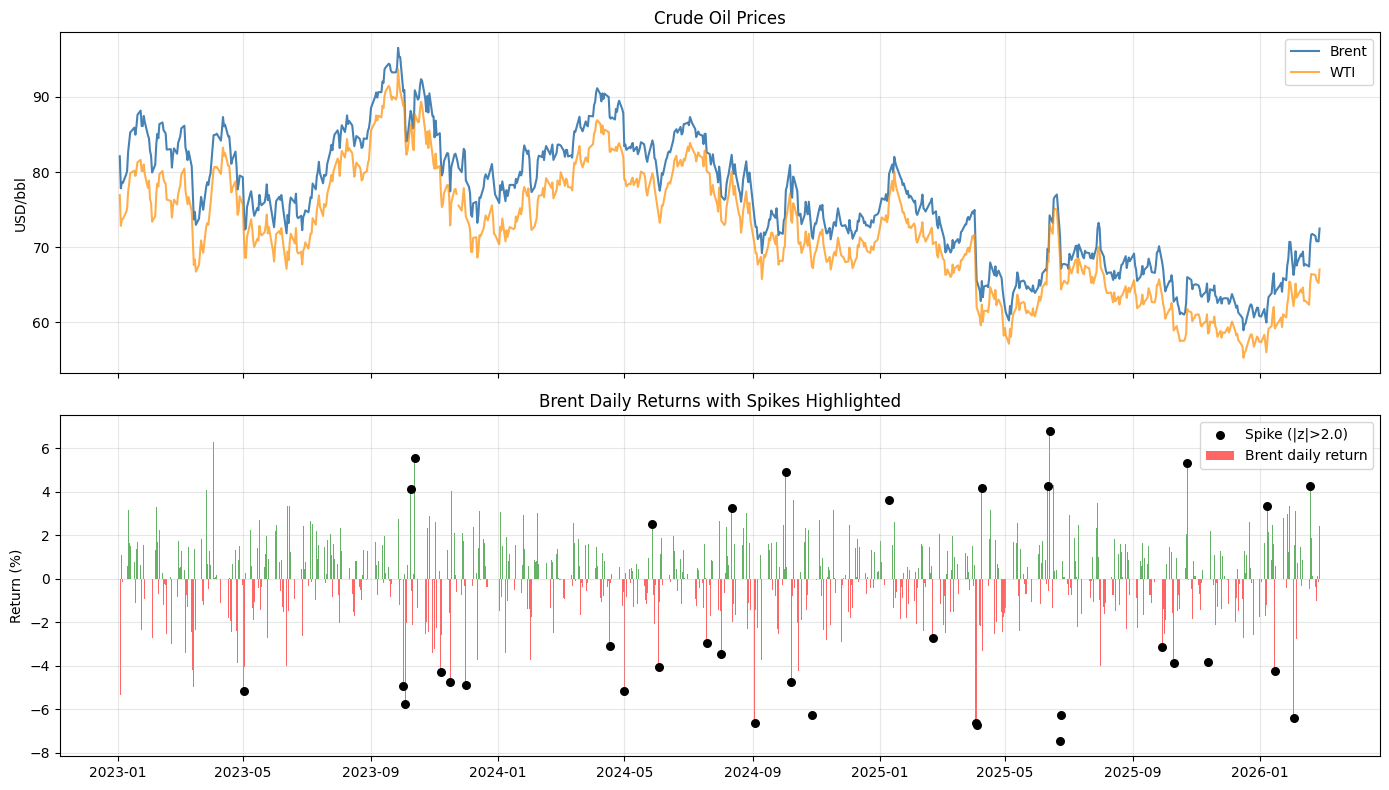

In [12]:
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(oil_df.index, oil_df['Brent'], label='Brent', color='steelblue')
ax1.plot(oil_df.index, oil_df['WTI'],   label='WTI',   color='darkorange', alpha=0.7)
ax1.set_title('Crude Oil Prices')
ax1.set_ylabel('USD/bbl')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(oil_ret.index, oil_ret['Brent'] * 100, color=[
    'red' if x < 0 else 'green' for x in oil_ret['Brent']
], alpha=0.6, label='Brent daily return')
# Mark spikes
spike_dates = spikes.index
ax2.scatter(spike_dates, oil_ret.loc[spike_dates, 'Brent'] * 100,
            color='black', zorder=5, s=30, label=f'Spike (|z|>{spike_threshold})')
ax2.set_title('Brent Daily Returns with Spikes Highlighted')
ax2.set_ylabel('Return (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: FX Response to Oil Spikes

In [13]:
# Daily log returns for FX
fx_ret = np.log(fx_df / fx_df.shift(1))

# Align oil and FX log returns on common dates
combined = oil_ret[['Brent']].join(fx_ret, how='inner').dropna()

# FX return on spike days
spike_dates = spikes.index
spike_days = combined.index.isin(spike_dates)
spike_df = combined[spike_days].copy()
spike_df['brent_direction'] = spike_df['Brent'].apply(lambda x: 'rally' if x > 0 else 'crash')

# Average FX log return on oil rally vs crash days
fx_cols = [c for c in combined.columns if c != 'Brent']
avg_fx_on_spike = spike_df.groupby('brent_direction')[fx_cols].mean() * 100

print("Average FX log return (%) on oil spike days:")
print("(Positive = USD strengthens / EM ccy weakens for USD/EM pairs)")
avg_fx_on_spike.T.sort_values('rally')

Average FX log return (%) on oil spike days:
(Positive = USD strengthens / EM ccy weakens for USD/EM pairs)


brent_direction,crash,rally
USDNOK,0.313038,-0.038928
USDCOP,0.293073,-0.020249
USDPHP,0.050686,0.054788
USDBRL,0.239510,0.074403
USDINR,-0.069999,0.113568
USDTHB,0.111905,0.130085
USDMXN,0.175385,0.151637
USDJPY,-0.184036,0.195827
USDIDR,0.056697,0.212258
USDMYR,0.010660,0.215877


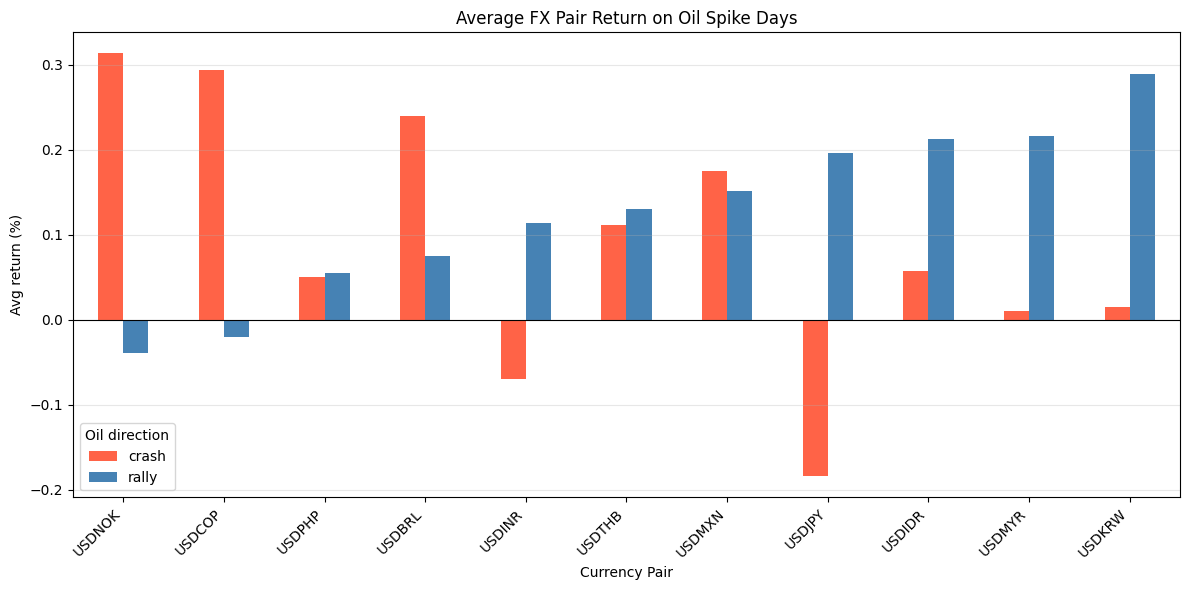

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
avg_fx_on_spike.T.sort_values('rally').plot(kind='bar', ax=ax, color=['tomato', 'steelblue'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average FX Pair Return on Oil Spike Days')
ax.set_ylabel('Avg return (%)')
ax.set_xlabel('Currency Pair')
ax.legend(title='Oil direction')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 5: Rolling Correlation — Oil vs FX

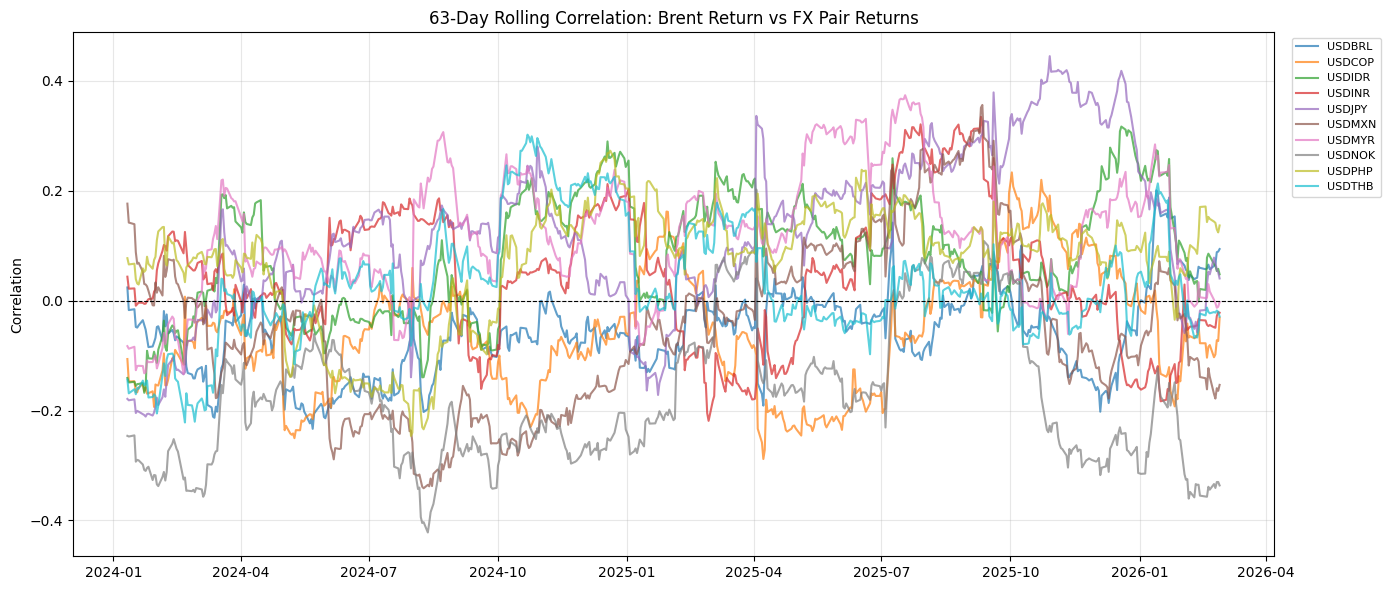

In [9]:
window = 63  # ~3 months

rolling_corr = combined[fx_cols].apply(
    lambda col: col.rolling(window).corr(combined['Brent'])
)

fig, ax = plt.subplots(figsize=(14, 6))
for col in fx_cols:
    ax.plot(rolling_corr.index, rolling_corr[col], label=col, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'{window}-Day Rolling Correlation: Brent Return vs FX Pair Returns')
ax.set_ylabel('Correlation')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6: Correlation Heatmap

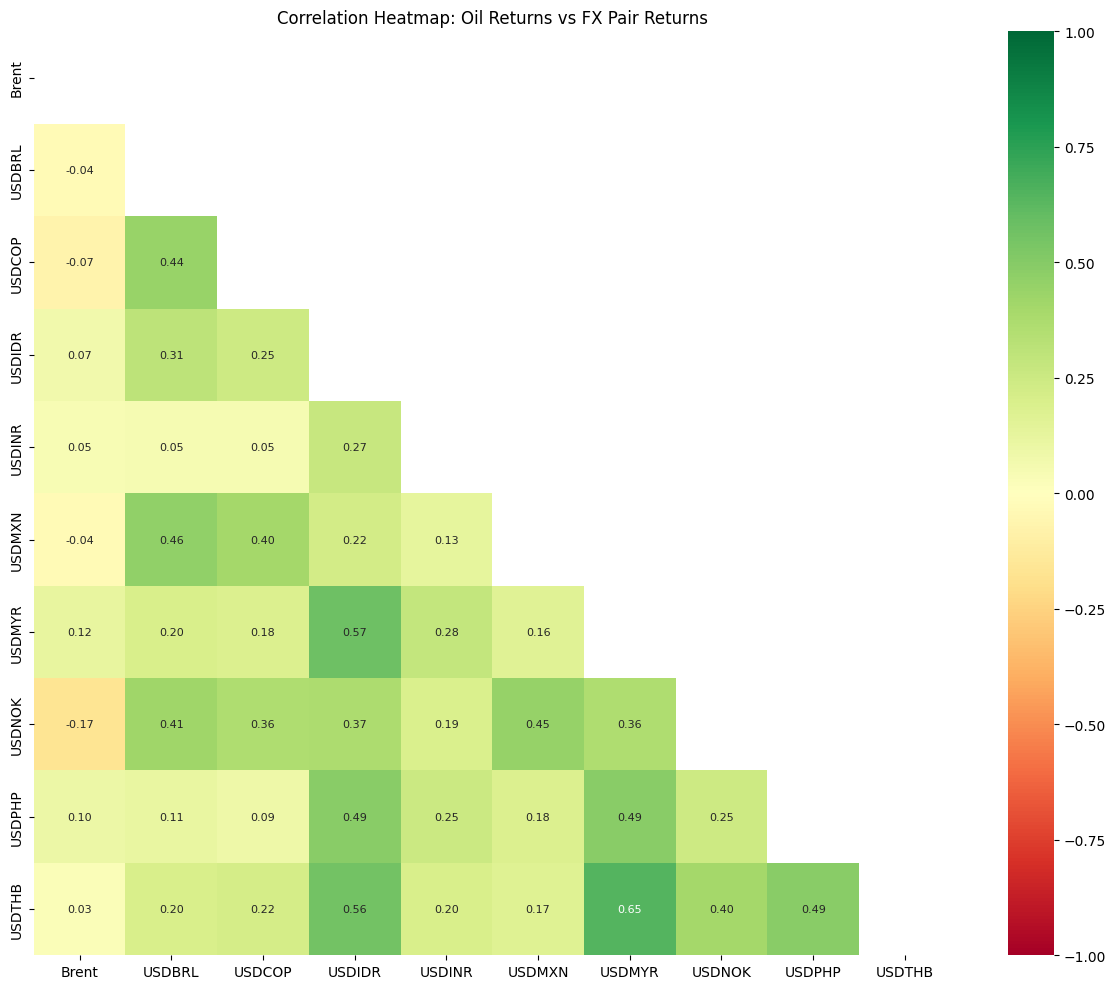

In [32]:
corr_matrix = combined.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap: Oil Returns vs FX Pair Returns')
plt.tight_layout()
plt.show()

## Section 7: Interactive Scatter — Brent vs Selected FX

In [33]:
# Pick a few interesting pairs to plot interactively
pairs_to_plot = ['USDMXN', 'USDINR', 'USDMYR', 'USDBRL', 'USDNOK']
pairs_to_plot = [p for p in pairs_to_plot if p in combined.columns]

fig = make_subplots(
    rows=1, cols=len(pairs_to_plot),
    subplot_titles=pairs_to_plot,
    shared_yaxes=False
)

for i, pair in enumerate(pairs_to_plot, 1):
    sub = combined[['Brent', pair]].dropna()
    fig.add_trace(
        go.Scatter(
            x=sub['Brent'] * 100,
            y=sub[pair] * 100,
            mode='markers',
            marker=dict(size=4, opacity=0.5),
            name=pair,
            text=sub.index.strftime('%Y-%m-%d'),
            hovertemplate=(
                '%{text}<br>'
                f'Brent: %{{x:.2f}}%<br>'
                f'{pair}: %{{y:.2f}}%'
            )
        ),
        row=1, col=i
    )

fig.update_layout(
    title='Brent Daily Return (%) vs FX Pair Daily Return (%)',
    height=450,
    showlegend=False,
    template='plotly_white'
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Section 8: OLS Beta — FX Sensitivity to Oil

In [34]:
results = []
for pair in fx_cols:
    sub = combined[['Brent', pair]].dropna()
    slope, intercept, r, p, se = stats.linregress(sub['Brent'], sub[pair])
    results.append({
        'pair': pair,
        'beta': slope,
        'r_squared': r**2,
        'p_value': p,
        'significant': p < 0.05
    })

ols_df = pd.DataFrame(results).set_index('pair').sort_values('beta')
print("OLS Beta: 1% Brent move → FX pair move (negative = EM ccy strengthens on oil rally for oil exporters)")
ols_df.style.format({'beta': '{:.4f}', 'r_squared': '{:.3f}', 'p_value': '{:.4f}'})

OLS Beta: 1% Brent move → FX pair move (negative = EM ccy strengthens on oil rally for oil exporters)


,beta,r_squared,p_value,significant
pair,,,,
USDNOK,-0.0428,0.028,0.0001,True
USDCOP,-0.0209,0.005,0.0868,False
USDMXN,-0.0116,0.001,0.3698,False
USDBRL,-0.0092,0.001,0.4080,False
USDINR,0.0039,0.002,0.2861,False
USDTHB,0.0076,0.001,0.4696,False
USDIDR,0.0121,0.005,0.0934,False
USDPHP,0.0153,0.009,0.0235,True
USDMYR,0.0238,0.015,0.0032,True


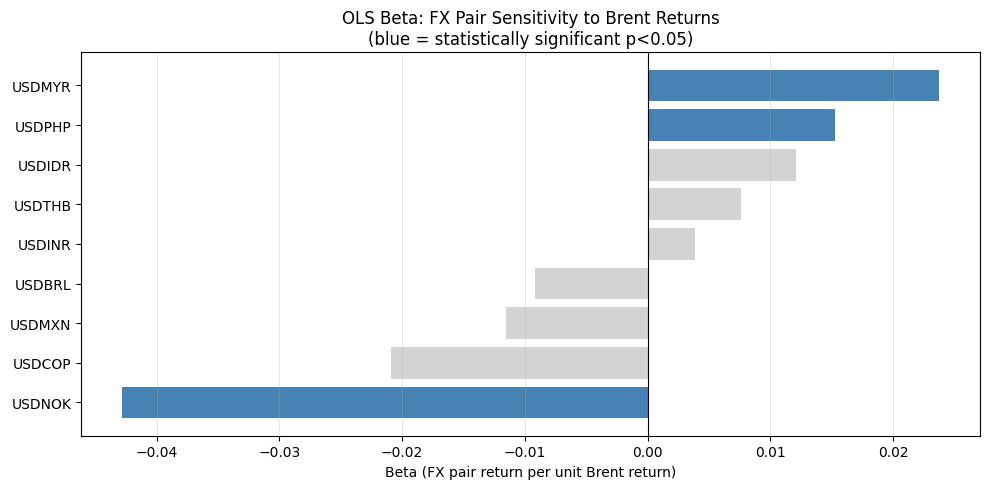

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if sig else 'lightgray' for sig in ols_df['significant']]
bars = ax.barh(ols_df.index, ols_df['beta'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('OLS Beta: FX Pair Sensitivity to Brent Returns\n(blue = statistically significant p<0.05)')
ax.set_xlabel('Beta (FX pair return per unit Brent return)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()